In [208]:
import pandas as pd
import sys
import importlib
from pathlib import Path

In [209]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [210]:
sys.path.append("../src")
import eda_utils as eda
import visualization as visual
import data_splitting as split
import preprocessing as prep
import constants as const
import knn as knn

importlib.reload(eda)
importlib.reload(visual)
importlib.reload(split)
importlib.reload(prep)
importlib.reload(const)
importlib.reload(knn)

<module 'knn' from '/home/abril/UdeSA/ML/TP_Final_ML/notebooks/../src/knn.py'>

In [211]:
dataset = pd.read_csv("../data/pf_suvs.csv")

<h1 style="
    background-color: #d0ebff;
    color: #1a1a1a;
    display: inline-block;
    padding: 10px 18px;
    border-radius: 10px;
    font-size: 32px;
">
Preprocessing Pipeline
</h1>

Este notebook concentra las transformaciones que convierten el dataset original en los archivos que se usan para EDA final, feature engineering y modelado.

El flujo queda separado en etapas:

1. Limpieza inicial de columnas irrelevantes o constantes.
2. Corrección de valores inconsistentes y conversión monetaria.
3. Estandarización semántica de categorías.
4. Recuperación de información desde columnas de texto.
5. Tratamiento de faltantes y outliers.
6. Guardado del dataset preprocesado.
7. Split de entrenamiento/validación y generación del one-hot base para modelado.

In [ ]:
TARGET = "Precio"

categorical_columns = [
    "Marca",
    "Modelo",
    "Color",
    "Tipo de vendedor",
    "Tipo de combustible",
    "Transmisión",
]

print(f"Dataset original: {dataset.shape[0]} filas y {dataset.shape[1]} columnas")


Dataset original: 18254 filas y 18 columnas


In [213]:
print(f"Dataset original: {dataset.shape[0]} filas y {dataset.shape[1]} columnas")

Dataset original: 18254 filas y 18 columnas


<h3
style="background-color: #343a40; color: #ffffff; 
display: inline-block; 
padding: 6px 10px;
border-radius: 6px;">
Initial Preprocessing
</h3>

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Drop irrelevant columns
</div>

En primer lugar, se eliminan aquellas columnas que no aportan información útil para el entrenamiento de los modelos predictivos.

Por un lado, la columna **`Unnamed: 0`** corresponde al índice del dataset exportado a CSV y no contiene información descriptiva sobre los vehículos.

In [214]:
dataset_processed = prep.drop_irrelevant_columns(dataset.copy(), columns_to_drop=["Unnamed: 0"])

Por otro lado, se verifica si existen variables constantes, es decir, columnas cuyos valores son iguales para todas las observaciones. Este tipo de variables no aportan capacidad predictiva, ya que no permiten diferenciar entre ejemplos

In [215]:
eda.get_constant_columns(dataset_processed).style.hide(axis="index")

column,unique_value
Tipo de carrocería,SUV


Se observa que la única variable constante del conjunto de datos es **`Tipo de carrocería`**, cuyo valor es **"SUV"** para todas las publicaciones.

Dado que el dataset está compuesto exclusivamente por vehículos SUV, esta variable no aporta información discriminativa y, por lo tanto, se elimina del conjunto de datos.

In [216]:
dataset_processed = prep.drop_irrelevant_columns(dataset_processed, columns_to_drop = ["Tipo de carrocería"])

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Remove inconsistent values
</div>

Como se oservó anteriormente, las features `Año` y `Puertas` presentan valores sin sentido, por lo que se delimitó un rango de valores aceptables. Aquellos años superiores al 2025 (año de creación del dataset) fueron eliminados, al igual que los autos con más de cinco puertas. Por suerte, son tan solo diez muestras a eliminar

In [217]:
print("=== Chequeo de valores atípicos simples ===")
print(f"Año máximo: {dataset['Año'].max()}")
print(f"Cantidad de años mayores a 2025: {(dataset['Año'] > 2025).sum()}")
print()
print(f"Cantidad máxima de puertas: {dataset['Puertas'].max()}")
print(f"Cantidad de observaciones con más de 5 puertas: {(dataset['Puertas'] > 5).sum()}")

=== Chequeo de valores atípicos simples ===
Año máximo: 436694.0
Cantidad de años mayores a 2025: 1

Cantidad máxima de puertas: 60252.0
Cantidad de observaciones con más de 5 puertas: 9


In [ ]:
initial_rules ={
    "Año": {"max": 2025},
    "Puertas": {"max": 5},
}

dataset_processed = prep.remove_invalid_values(dataset_processed, initial_rules)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Convert prices to USD
</div>

Para entrenar un modelo predictivo consistente, todos los precios deben estar expresados en una misma moneda. Dado que el dataset contiene publicaciones en pesos argentinos y en dólares estadounidenses, se convierten los precios publicados en pesos a USD.

El dataset fue construido entre el 13/05/2025 y el 30/05/2025. Por este motivo, se utiliza como tipo de cambio el promedio de la cotización diaria del dólar oficial vendedor del Banco Nación durante ese período.

Fuente: [Cotización diaria del Dólar Banco Nación (BNA) - Mayo 2025](https://dolarhistorico.com/dolar-banco-nacion/mes/mayo-2025)

In [219]:
official_usd_sell = const.OFFICIAL_USD_SELL
pd.Series(official_usd_sell, name="dolar_oficial_vendedor").to_frame()


,dolar_oficial_vendedor
2025-05-13,1150.0
2025-05-14,1150.0
2025-05-15,1150.0
2025-05-16,1160.0
2025-05-19,1155.0
2025-05-20,1160.0
2025-05-21,1160.0
2025-05-22,1155.0
2025-05-23,1150.0
2025-05-26,1160.0


In [220]:
EXCHANGE_RATE = const.EXCHANGE_RATE
print(f"El tipo de cambio utilizado es de ${EXCHANGE_RATE:.2f}")


El tipo de cambio utilizado es de $1163.21


In [221]:
dataset_processed = prep.convert_peso_prices_to_usd(dataset_processed, EXCHANGE_RATE)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Kilometers to int
</div>

Como se observó, la columna **`Kilómetros`** fue cargada como *string*, por lo que hay que convertirla a float, teniendo en cuenta que algunos valores incluyen la unidad "km", la cual será eliminada.

In [222]:
dataset_processed["Kilómetros"] = (dataset_processed["Kilómetros"].apply(prep.extract_first_integer))

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Semantic Cleaning of Categorical Features
</div>

En esta etapa se aplican los reemplazos necesarios para estandarizar las variables categóricas identificadas previamente. Para ello, primero cada valor se normaliza mediante `normalize_category_text`, que transforma el texto a minúsculas, elimina tildes y homogeniza separadores y espacios. Luego, `apply_semantic_mapping` reemplaza cada variante por una categoría final definida manualmente mediante diccionarios de mapeo.

Los mapas de reemplazo se construyeron únicamente para aquellos casos en los que la equivalencia semántica era clara, evitando agrupar categorías que, aunque similares en su escritura, representan conceptos diferentes.

Además, los valores faltantes se mantienen como la categoría explícita `missing`. De esta manera, la ausencia de información se conserva como una señal potencialmente informativa para el modelo, en lugar de perderse durante las etapas posteriores de codificación

Para construir los mapeos semánticos se realizó una revisión manual de las categorías detectadas en el dataset. El objetivo fue unificar distintas escrituras de un mismo valor, corregir errores tipográficos evidentes y agrupar categorías que representaban conceptos muy similares. Por ejemplo, se unificaron marcas escritas con errores (`Jetour` y `Jetur`), variantes de modelos equivalentes o muy cercanas, y colores expresados con distintos nombres comerciales o tonalidades similares.

El criterio utilizado fue exploratorio y conservador: solo se agruparon valores cuando la equivalencia era clara o cuando la diferencia entre categorías no parecía aportar información relevante para el modelo. De esta forma, se buscó reducir la cardinalidad y evitar que pequeñas variaciones de escritura fragmenten artificialmente las variables categóricas.

In [ ]:
BRAND_MAP = const.BRAND_MAP
MODEL_MAP = const.MODEL_MAP
COLOR_MAP = const.COLOR_MAP
FUEL_TYPE_MAP = const.FUEL_TYPE_MAP
TRANSMISSION_MAP = const.TRANSMISSION_MAP

In [224]:
dataset_processed = prep.apply_semantic_mapping(dataset_processed, column = "Marca", category_map = BRAND_MAP)

dataset_processed = prep.apply_semantic_mapping(dataset_processed, column = "Modelo", category_map = MODEL_MAP)

dataset_processed = prep.apply_semantic_mapping(dataset_processed, column = "Color", category_map = COLOR_MAP)

dataset_processed = prep.apply_semantic_mapping(dataset_processed, column = "Tipo de combustible", category_map = FUEL_TYPE_MAP)

dataset_processed = prep.apply_semantic_mapping(dataset_processed, column = "Transmisión", category_map = TRANSMISSION_MAP)

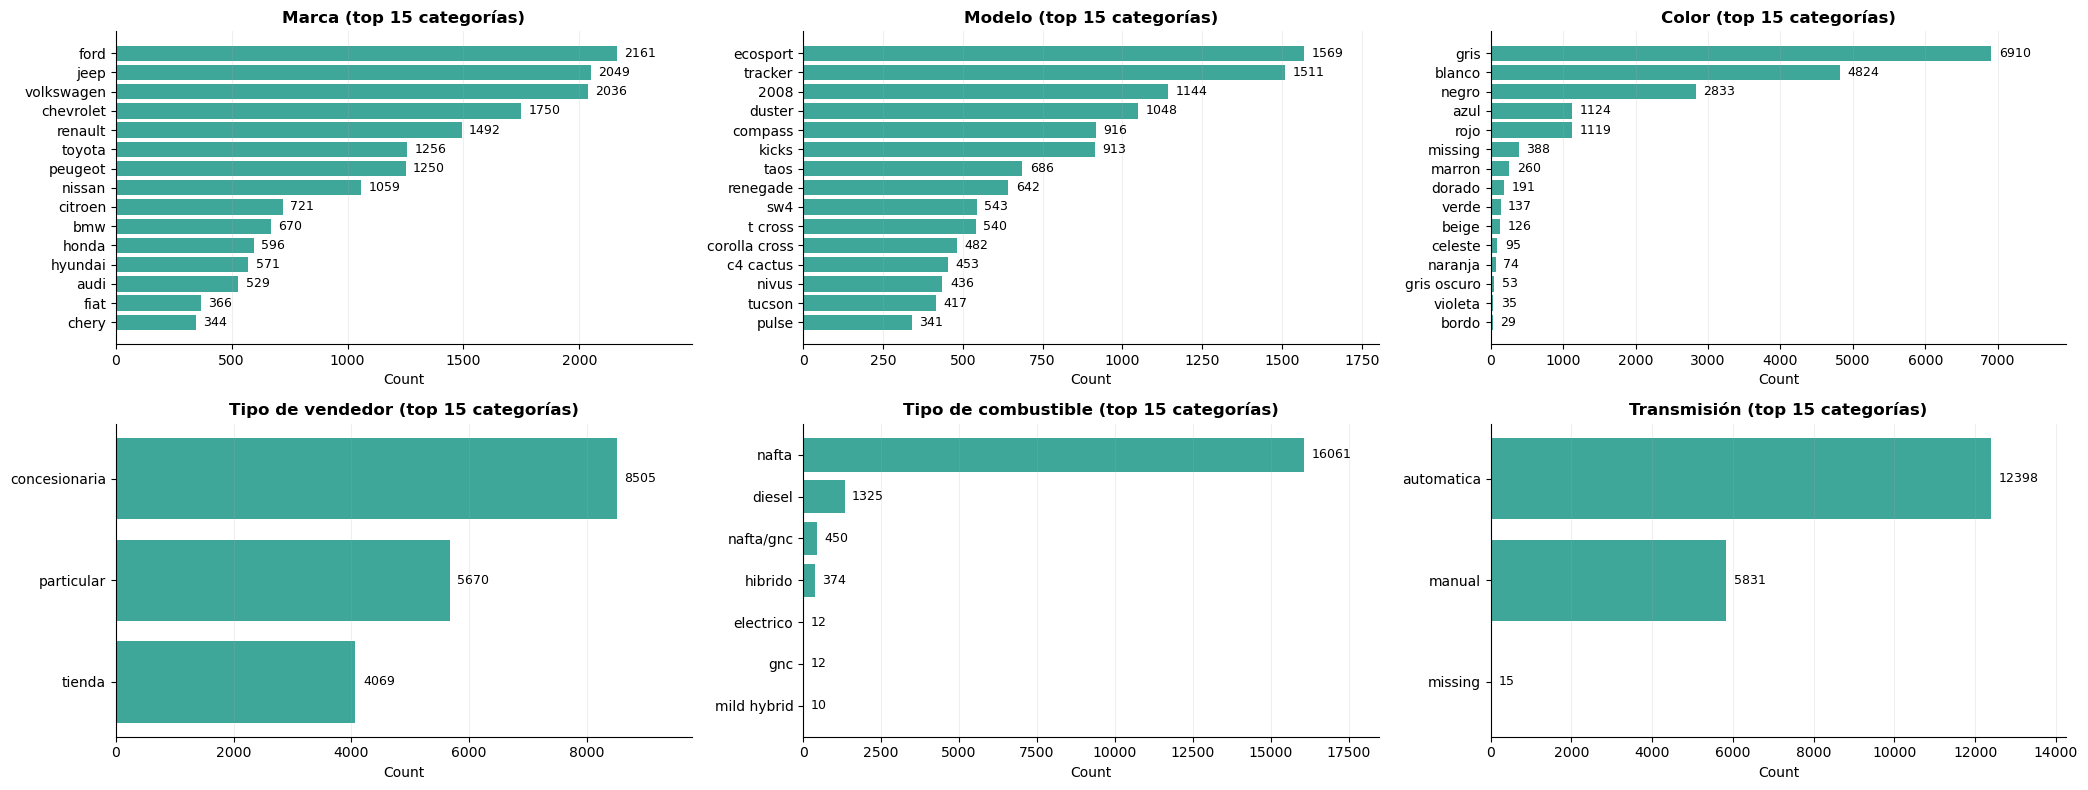

In [225]:
visual.plot_compact_value_counts(
    dataset_processed,
    columns=categorical_columns,
    top_n=15,
    n_cols=3
)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Encode binary features
</div>

Dentro del conjunto de variables categóricas, la única que representa información binaria de tipo **sí/no** es `Con cámara de retroceso`. Para que pueda ser utilizada por los modelos predictivos, esta variable se transforma a una representación numérica:

- **1** si el vehículo tiene cámara de retroceso
- **0** si el vehículo no tiene cámara de retroceso

In [226]:
camera_map = {
    "sí": 1,
    "si": 1,
    "no": 0,
}

dataset_processed = prep.map_column_values(dataset_processed, column = "Con cámara de retroceso", value_map = camera_map)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Missing Value Handling
</div>

En esta sección se revisan algunos valores faltantes que pueden recuperarse a partir de información textual disponible en otras columnas del dataset, principalmente `Título`, `Descripción` y `Versión`.

No se imputan todos los valores faltantes, sino únicamente aquellos casos en los que el texto contiene una señal explícita y suficientemente clara. Para variables categóricas, como `Color` y `Transmisión`, primero se buscan menciones de categorías conocidas luego de aplicar la misma normalización semántica usada en la limpieza previa. Si se detecta una única categoría, el valor se completa; si aparecen varias categorías posibles, el caso se mantiene sin imputar para evitar asignaciones ambiguas.

Para variables con una estructura más específica, como `Motor` o `Con cámara de retroceso`, se usan extractores diseñados para detectar patrones concretos dentro del texto. En `Motor`, se buscan valores de cilindrada y señales de turbo. En `Con cámara de retroceso`, solo se completa el valor cuando aparece una mención explícita de la cámara.

Este criterio permite recuperar información que ya estaba presente en la publicación sin introducir imputaciones estadísticas todavía. Los valores que no puedan recuperarse con suficiente confianza se mantienen como faltantes o como categoría `missing`, y se revisan más adelante según su relevancia para el modelado.

### Color
Se buscan menciones de colores en las columnas de texto y se completan únicamente los casos con una sola categoría detectada.

In [227]:
color_row_mentions = eda.count_category_mentions_in_text(dataset_processed, target_col="Color", text_cols=("Título", "Descripción", "Versión"),
                                    category_map=COLOR_MAP, only_missing_target=True, only_rows_with_mentions=True,)
color_row_mentions.style.hide(axis = "index")

row_index,Color_is_missing,matched_categories,n_category_mentions
4407,True,azul,1
4476,True,blanco | negro,2
6776,True,gris,1
8804,True,beige,1
10789,True,blanco | negro,2
10884,True,azul,1
11095,True,blanco | gris | gris oscuro | negro,4
11460,True,blanco | negro,2
13138,True,negro,1
13220,True,gris | negro,4


In [228]:
dataset_processed, color_fill_audit = prep.fill_missing_from_single_text_match(dataset_processed, target_col="Color", matches_df = color_row_mentions,)
color_fill_audit.style.hide(axis = "index")

Missing rows in 'Color': 388
Filled from text matches: 8
Still missing after text matches search: 380


row_index,matched_categories,n_unique_matches,fill_value,target_col
4407,azul,1.000000,azul,Color
6776,gris,1.000000,gris,Color
8804,beige,1.000000,beige,Color
10884,azul,1.000000,azul,Color
13138,negro,1.000000,negro,Color
14804,blanco,1.000000,blanco,Color
15343,gris,1.000000,gris,Color
16483,blanco,1.000000,blanco,Color


### Motor
Se extrae información de cilindrada desde el texto y se conserva la señal de turbo cuando aparece explícitamente.

In [ ]:
ENGINE_TEXT_MAP = const.ENGINE_TEXT_MAP

In [230]:
engine_row_mentions = eda.count_category_mentions_in_text(dataset_processed, target_col="Motor", text_cols=("Título", "Descripción", "Versión"), 
                                                          category_map=ENGINE_TEXT_MAP, only_missing_target=True, only_rows_with_mentions=True,)

engine_row_mentions.style.hide(axis = "index")

row_index,Motor_is_missing,matched_categories,n_category_mentions
209,True,2.5,2
219,True,1.0,4
2488,True,1.6,2
2764,True,1.8,3
3624,True,1.5,6
3760,True,1.6,4
4418,True,1.6,4
6095,True,1.5,3
7915,True,1.5,2
8264,True,1.0,2


In [ ]:
dataset_processed, engine_audit = prep.fill_missing_from_text(dataset_processed, target_col="Motor", text_cols=("Versión", "Título", "Descripción"), 
                                                              extractor=prep.extract_engine_liters_from_text, extracted_col_name="extracted_engine",)

engine_audit.head(10).style.hide(axis = "index")

### Transmisión
Se buscan variantes textuales de transmisión manual o automática y se imputan solo los casos no ambiguos.

In [ ]:
TRANSMISSION_TEXT_MAP = const.TRANSMISSION_TEXT_MAP

In [ ]:
transmission_row_mentions = eda.count_category_mentions_in_text(dataset_processed, target_col="Transmisión", text_cols=("Título", "Descripción", "Versión"), category_map=TRANSMISSION_TEXT_MAP, 
                                                                only_missing_target=True, only_rows_with_mentions=True,)

transmission_row_mentions.style.hide(axis = "index")

row_index,Transmisión_is_missing,matched_categories,n_category_mentions
2194,True,automatica,2
5507,True,automatica,2
7663,True,automatica,4
12920,True,automatica,2
12979,True,automatica,2
17594,True,automatica,4
17665,True,automatica | manual,8


In [234]:
dataset_processed, transmission_fill_audit = prep.fill_missing_from_single_text_match( dataset_processed, target_col="Transmisión", matches_df=transmission_row_mentions,)
transmission_fill_audit.style.hide(axis = "index")

Missing rows in 'Transmisión': 15
Filled from text matches: 6
Still missing after text matches search: 9


row_index,matched_categories,n_unique_matches,fill_value,target_col
2194,automatica,1.000000,automatica,Transmisión
5507,automatica,1.000000,automatica,Transmisión
7663,automatica,1.000000,automatica,Transmisión
12920,automatica,1.000000,automatica,Transmisión
12979,automatica,1.000000,automatica,Transmisión
17594,automatica,1.000000,automatica,Transmisión


### Con cámara de retroceso

La variable `Con cámara de retroceso` presenta una proporción elevada de valores faltantes. Por este motivo, no se eliminan las muestras con valores nulos ni se asume directamente que un valor faltante implica ausencia de cámara. En cambio, se aplica una estrategia de imputación progresiva, utilizando primero fuentes de información más confiables y luego métodos más aproximados. Esta estrategia busca reducir la pérdida de información y evitar eliminar una gran cantidad de observaciones, manteniendo un criterio conservador en las primeras etapas y dejando los métodos más aproximados para el final.

La imputación se realiza en 4 etapas:

1. **Imputación a partir del texto de la publicación:** se inspeccionan las columnas `Título`, `Descripción` y `Versión`. Cuando el texto menciona explícitamente la presencia de cámara de retroceso, el valor faltante se imputa como `1`

In [ ]:
CAMARA_MAP = const.BACKUP_CAMERA_TEXT_MAP

In [236]:
camera_row_mentions = eda.count_category_mentions_in_text(
    dataset_processed,
    target_col="Con cámara de retroceso",
    text_cols=("Título", "Descripción", "Versión"),
    category_map=CAMARA_MAP,
    only_missing_target=True,
    only_rows_with_mentions=True,
)

camera_row_mentions.head(10)

,row_index,Con cámara de retroceso_is_missing,matched_categories,n_category_mentions
0,4,True,camara de retroceso,1
1,45,True,camara de retroceso,1
2,54,True,camara de retroceso,1
3,175,True,camara de retroceso,1
4,269,True,camara de retroceso,1
5,276,True,camara de retroceso,1
6,292,True,camara de retroceso,1
7,435,True,camara de retroceso,1
8,446,True,camara de retroceso,1
9,541,True,camara de retroceso,1


In [ ]:
dataset_processed, camera_audit = prep.fill_missing_from_text(dataset_processed, target_col="Con cámara de retroceso", text_cols=("Título", "Descripción", "Versión"), 
                                                              extractor=prep.extract_backup_camera, extracted_col_name="extracted_camera")

camera_audit[["row_index", "text_used", "extracted_camera"]].sample(5, random_state=42).style.hide(axis="index")

2. **Imputación por consenso de vehículos similares:** para los casos que continúan faltantes, se agrupan vehículos con la misma combinación de `Marca`, `Modelo`, `Año` y `Versión`. Dentro de cada grupo se observan únicamente los registros que sí tienen un valor conocido para `Con cámara de retroceso`. Si hay al menos `min_known_count` registros conocidos y todos coinciden en el mismo valor (`0` o `1`), se utiliza ese valor para completar los faltantes del grupo. Si el grupo tiene valores contradictorios o no alcanza la cantidad mínima de registros conocidos, no se imputa nada en esta etapa.

In [238]:
dataset_processed, camera_imputation_audit_version = (
    prep.impute_missing_by_group_consensus(
        dataset_processed,
        target_col="Con cámara de retroceso",
        group_cols=("Marca", "Modelo", "Año", "Versión"),
        min_known_count=2,
    )
)

camera_imputation_audit_version.sample(5, random_state=42).style.hide(axis="index")

Missing rows in 'Con cámara de retroceso': 13070
Filled from group consensus: 5568
Still missing after group consensus search: 7502


row_index,group_key,n_known_group_values,fill_value,target_col
3887,volkswagen | taos | 2024.0 | 1.4 250 tsi comfortline,5.000000,1.000000,Con cámara de retroceso
2596,jeep | compass | 2025.0 | 1.3 t270 serie s 4x2 at6,58.000000,1.000000,Con cámara de retroceso
1532,jeep | renegade | 2024.0 | 1.3t longitude at6 fwd,11.000000,1.000000,Con cámara de retroceso
3734,hyundai | tucson | 2008.0 | 2.0 n 2wd mt,3.000000,0.000000,Con cámara de retroceso
17907,nissan | kicks | 2025.0 | 1.6 exclusive cvt,10.000000,1.000000,Con cámara de retroceso


3. **Imputación por antigüedad del vehículo:** para los registros que continúan con valores faltantes, se imputan como `0` aquellos vehículos fabricados antes del año `2000`. Esta decisión se basa en que la cámara de retroceso no era una característica habitual en vehículos de producción masiva anteriores a ese período, por lo que su presencia en SUVs previas a 2000 resulta altamente improbable. 

Fuente: [Backup camera - Wikipedia](https://en.wikipedia.org/wiki/Backup_camera) y [Which Cars Have Backup Cameras? - CARFAX](https://www.carfax.com/buying/cars-with-standard-rearview-cameras).

In [239]:
dataset_processed = prep.impute_missing_by_year(dataset_processed, "Con cámara de retroceso", year_threshold = 2000)

Missing rows in 'Con cámara de retroceso': 7502
Filled by year rule: 126
Still missing after year rule: 7376


4. **Imputación mediante KNN:** como última etapa, los valores faltantes restantes de `Con cámara de retroceso` se imputan mediante KNN. Este método busca vehículos similares a partir de un conjunto de variables predictoras y estima el valor faltante utilizando los vecinos más cercanos. A diferencia de las etapas anteriores, esta estrategia no se basa en evidencia directa del texto ni en consenso exacto entre vehículos equivalentes, sino en similitud entre observaciones. Por este motivo, se utiliza al final del proceso, únicamente para los casos que no pudieron completarse con criterios más confiables. Metodológicamente, para evitar data leakage, el imputador KNN debe ajustarse únicamente con el conjunto de entrenamiento. Luego, la misma transformación aprendida se aplica sobre validación/test. De esta manera, la información de validación no participa en el cálculo de vecinos ni en las decisiones de imputación del entrenamiento.

In [240]:
# dataset_processed, camera_knn_audit = knn.impute_missing_knn(
#     dataset_processed,
#     target_col="Con cámara de retroceso",
#     feature_cols=["Año", "Kilómetros", "Precio"],
#     n_neighbors=5,
#     round_result=True,
#     clip_range=(0, 1),
# )

### Checking updated dataset

In [241]:
# Previous missing values
eda.missing_values_summary(dataset_processed).style.hide(axis = "index")

column,missing_count,missing_percentage
Con cámara de retroceso,7376,40.430000
Color,380,2.080000
Motor,17,0.090000
Transmisión,9,0.050000


In [242]:
# Current missing values
eda.missing_values_summary(dataset_processed).style.hide(axis = "index")

column,missing_count,missing_percentage
Con cámara de retroceso,7376,40.430000
Color,380,2.080000
Motor,17,0.090000
Transmisión,9,0.050000


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
New Columns to Represent Engine Feature
</div>

Para la variable `Motor`, se busca extraer información técnica que aparece escrita de distintas formas en el texto original. En particular, se recupera la cilindrada del motor y se conserva la presencia de turbo cuando esta información aparece explícitamente mencionada.

Ya se completaron algunos valores faltantes de `Motor` utilizando las columnas `Título`, `Descripción` y `Versión`. Para esto se identifican patrones confiables de cilindrada, como `1.6`, `2.0`, `1.5t`, `1.3 TCE`, `1.0 TSI` o valores en centímetros cúbicos como `1600 cc`. Cuando además se detectan expresiones asociadas a turbo, como `turbo`, `TSI`, `TDI`, `THP` o `TCE`, el valor imputado conservó esa información en el texto, por ejemplo `1.5 turbo`.

Luego, a partir de la columna `Motor` ya completada, se crean nuevas variables. La columna `Cilindrada` almacena la cilindrada extraída en litros como valor numérico, mientras que `Tiene turbo` indica si el motor presenta señales de turbo en el texto.

De esta forma, la información técnica contenida originalmente en `Motor` queda representada en columnas más limpias y comparables. Una vez creadas estas variables derivadas, la columna original `Motor` puede eliminarse del dataset final.

In [ ]:
TURBO = const.TURBO_PATTERNS

In [244]:
dataset_processed["Cilindrada"] = dataset_processed["Motor"].apply(prep.extract_engine_liters)
dataset_processed["Cilindrada"].isna().sum()

np.int64(311)

Algunas columas de `Motor` solo decian cosas como "Turboalimentado", por lo que tienen NAN a la hora de completar la cilindrada. Esos valores los podemos recuperar de las columnas `Versión` y `Descripción`

In [245]:
dataset_processed.loc[dataset_processed["Cilindrada"].isna(), "Cilindrada"] = dataset_processed.loc[dataset_processed["Cilindrada"].isna(), "Versión"].apply(prep.extract_engine_liters)
dataset_processed.loc[dataset_processed["Cilindrada"].isna(), "Cilindrada"] = dataset_processed.loc[dataset_processed["Cilindrada"].isna(), "Descripción"].apply(prep.extract_engine_liters)

In [246]:
print(dataset_processed["Cilindrada"].isna().sum())
print(dataset_processed["Cilindrada"].head())

22
0    1.5
1    2.0
2    1.4
3    1.5
4    2.4
Name: Cilindrada, dtype: float64


In [247]:
dataset_processed["Tiene turbo"] = dataset_processed["Motor"].apply(lambda value: prep.has_turbo(value, turbo_patterns = TURBO))

In [248]:
# Deleting Motor column as it has been processed into new features
dataset_processed = prep.drop_irrelevant_columns(dataset_processed, columns_to_drop = ["Motor"])

In [249]:
dataset_processed["Tiene turbo"].value_counts()

Tiene turbo
0    17874
1      370
Name: count, dtype: int64

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Text-Based Condition Features
</div>

Las columnas `Título`, `Descripción` y `Versión` tienen bastante información escrita por los vendedores. Parte de esa información ya la usamos para completar valores faltantes, como `Color`, `Motor`, `Transmisión` o `Con cámara de retroceso`.

Antes de eliminar estas columnas, se busca rescatar algunas señales simples que pueden ser útiles para predecir el precio. En vez de aplicar un modelo de NLP más complejo, se define un conjunto de palabras y frases de interés y se crean variables binarias que indiquen si esas expresiones aparecen o no en la publicación.

In [250]:
eda.frequent_words_table(dataset_processed, text_cols=("Título", "Descripción", "Versión"), top_n=50).style.hide(axis = "index")

word,count
000,7497
4x2,6118
cvt,4754
usado,4502
jeep,4004
volkswagen,3913
estado,3893
tsi,3851
usados,3845
4x4,3840


Teniendo un paneo general de las palabras más frecuengtes, vemos hay gran variedad de tipos de palabra. Muchas de estas están relacionadas al auto como producto, pero no hablan mucho del estado. Por eso, podríamos buscar la frecuencia de palabras agrupadas según el tipo de información que representan. Por ejemplo, algunas expresiones hacen referencia a documentación o papeles al día, otras a services o mantenimiento, otras al buen estado del vehículo, y otras a posibles detalles o daños. Vamos a gregar columnas binarias que representen estas condiciones.

Tambien, agregaremos una columna para identificar las publicaciones en las que no aparece ninguna de estas señales. Esto permite diferenciar entre autos con alguna información textual relevante y publicaciones donde el texto no aporta demasiado en este sentido.

In [ ]:
INTEREST_TERMS = const.INTEREST_TERMS

In [252]:
eda.count_interest_terms_in_text(dataset_processed, text_cols=("Título", "Descripción", "Versión"), terms_map=INTEREST_TERMS).style.hide(axis = "index")

term,count,row_count
papeles,3819,2842
service,3503,2611
buen_estado,2918,2299
impecable,1998,1748
cuidado,957,530
daño,69,65
detalles_uso,61,61
sin_choque,34,34


In [253]:
dataset_processed = prep.add_text_indicator_features(dataset_processed, text_cols=("Título", "Descripción", "Versión"), terms_map=INTEREST_TERMS, 
add_no_match_feature=True, no_match_feature_name="sin_condicion",)

In [254]:
dataset_processed.columns

Index(['Marca', 'Modelo', 'Año', 'Versión', 'Color', 'Tipo de combustible',
       'Puertas', 'Transmisión', 'Con cámara de retroceso', 'Kilómetros',
       'Título', 'Precio', 'Descripción', 'Tipo de vendedor', 'Cilindrada',
       'Tiene turbo', 'papeles', 'service', 'buen_estado', 'impecable',
       'cuidado', 'detalles_uso', 'daño', 'sin_choque', 'sin_condicion'],
      dtype='str')

Estas variables no dicen por sí solas si el precio debería subir o bajar. Por ejemplo, una mención a `service` o `impecable` podría estar asociada a un mejor estado del auto, mientras que una mención a `rayones` o `golpes` podría indicar lo contrario. La idea es dejar que el modelo aprenda esa relación a partir de los datos.

Una vez extraídas estas señales, las columnas originales de texto no se usan directamente en los modelos base. 
Se conservan en los archivos pre-one-hot para mantener trazabilidad y se descartan al cargar las matrices modelables cuando corresponde.


In [255]:
# dataset_processed = prep.drop_irrelevant_columns(dataset_processed,columns_to_drop=["Título", "Descripción", "Versión"])

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Final Missing Value Encoding
</div>

Antes de separar el dataset y aplicar one-hot encoding, se completan los valores faltantes restantes en las variables categóricas. En lugar de eliminar estas observaciones o imputarlas con una categoría mayoritaria, se reemplaza cada faltante por una categoría explícita asociada a su columna.

Por ejemplo, un valor faltante en `Color` se reemplaza por `missing_Color`, mientras que un faltante en `Transmisión` se reemplaza por `missing_Transmisión`. Esto permite conservar la información de que el dato no estaba disponible, y deja que el modelo aprenda si esa ausencia tiene alguna relación con el precio.

In [256]:
dataset_processed = prep.fill_missing_with_value(dataset_processed)                                                     

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Outliers Detection
</h3>

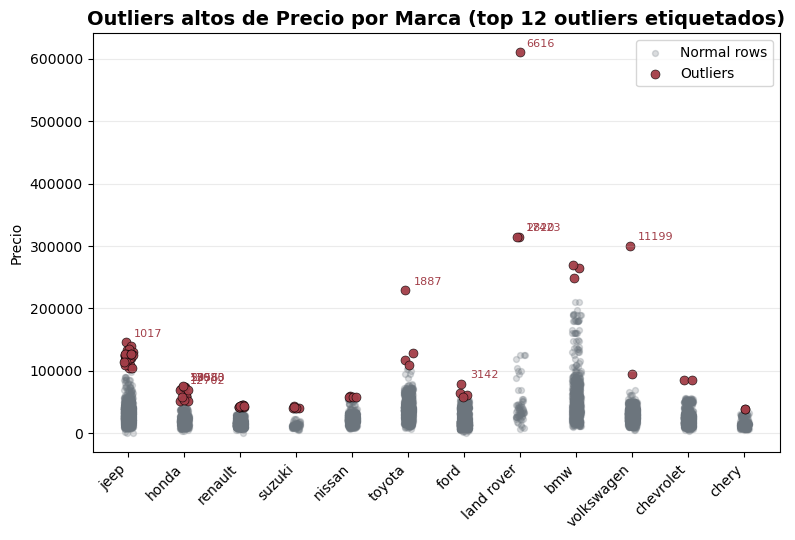

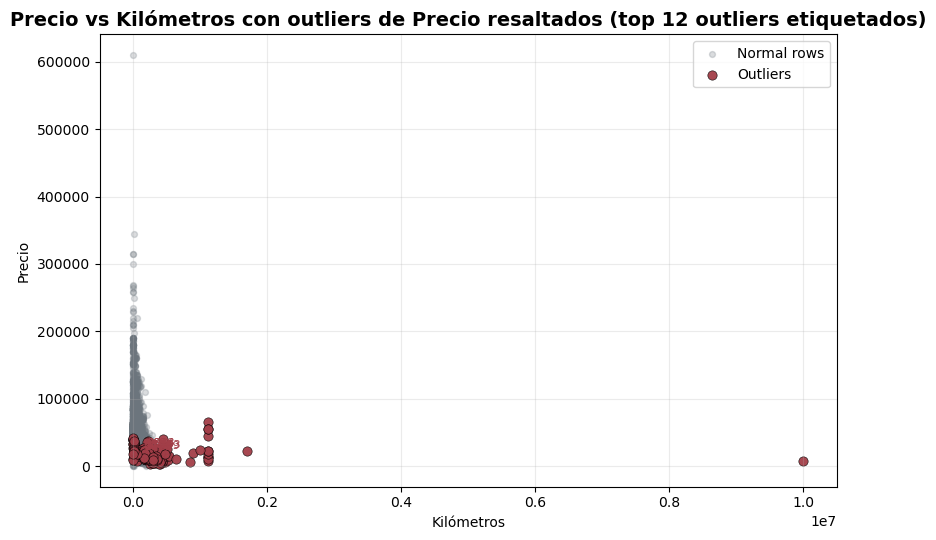

In [257]:
price_outliers = visual.plot_iqr_outliers(dataset_processed, value_col="Precio", group_col="Marca", context_cols="all",
                                          min_group_size=50, side="high", top_n_labels=12, title="Outliers altos de Precio por Marca", iqr_multiplier = 4.0)

price_km_outliers = visual.plot_iqr_outlier_scatter(dataset_processed, x_col="Kilómetros", y_col="Precio",outlier_col="Kilómetros",group_col="Marca", 
context_cols="all", min_group_size=50,side="high",title="Precio vs Kilómetros con outliers de Precio resaltados",)

Observamos que los outliers detectados con iqr no son del todo válidos. Autos 0km no deberían ser outliers, ni tampoco autos con precios de $USD 250.000 que refieren a marcas de alta gama. Por este motivo, utilizaremos un rango definido por nosotras para delimitar los valores de estos features.

In [ ]:
rules = {
    "Precio": {"method": "fixed", "min": 1000, "max": 400_000},
    "Kilómetros": {"method": "fixed", "min": 0, "max": 600_000},
}

# Inspect possible outliers
df_flagged = prep.detect_outliers(dataset_processed, rules, mode="flag")
df_flagged[df_flagged["is_outlier"]].drop(columns=["Descripción"]).head(20).style.hide(axis="index")


In [259]:
# Deleting outliers
dataset_processed = prep.detect_outliers(dataset_processed, rules, mode="drop")
print()
print(dataset_processed.shape)

Total rows flagged as outliers (any column): 21 (0.12%)
    column method  allow_zero  lower_bound  upper_bound  outliers_found  outlier_%
    Precio  fixed       False         1000       400000               4       0.02
Kilómetros  fixed       False            0       600000              17       0.09

(18223, 25)


Podríamos observar además, si hay algún outlier por marca. Son las marcas de alta gama las que tienen autos de mas de 100 mil dólares, por loq ue podríamos analizar si hay algun precio qu ehaga ruido

======================== Outliers por Marca ========================
Filtered out 8 categories with fewer than 10 rows.
Plotting 30 categories split into 3 charts.


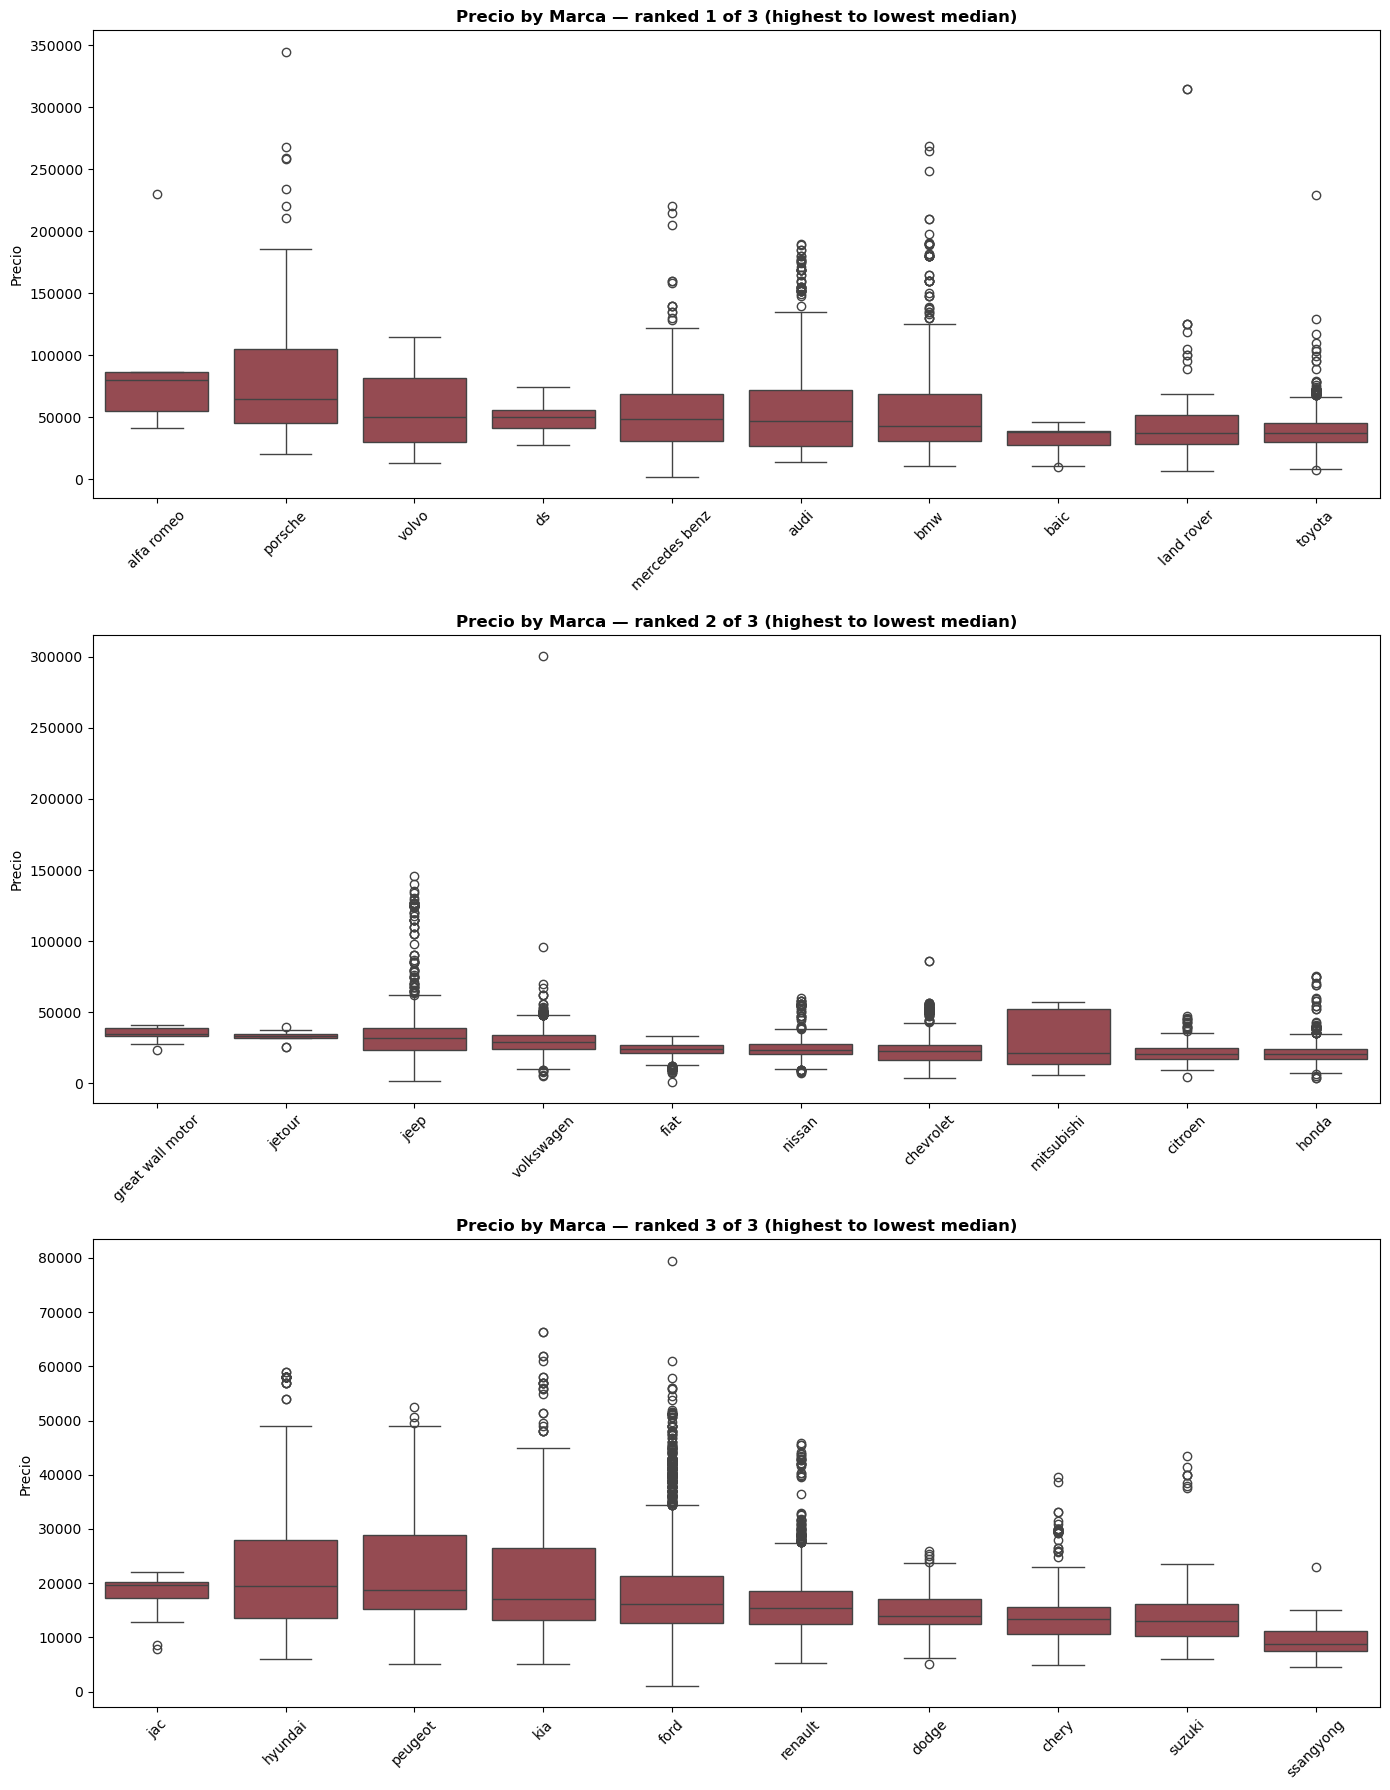

======================== Outliers por Modelo ========================
Filtered out 41 categories with fewer than 15 rows.
Plotting 90 categories split into 4 charts.


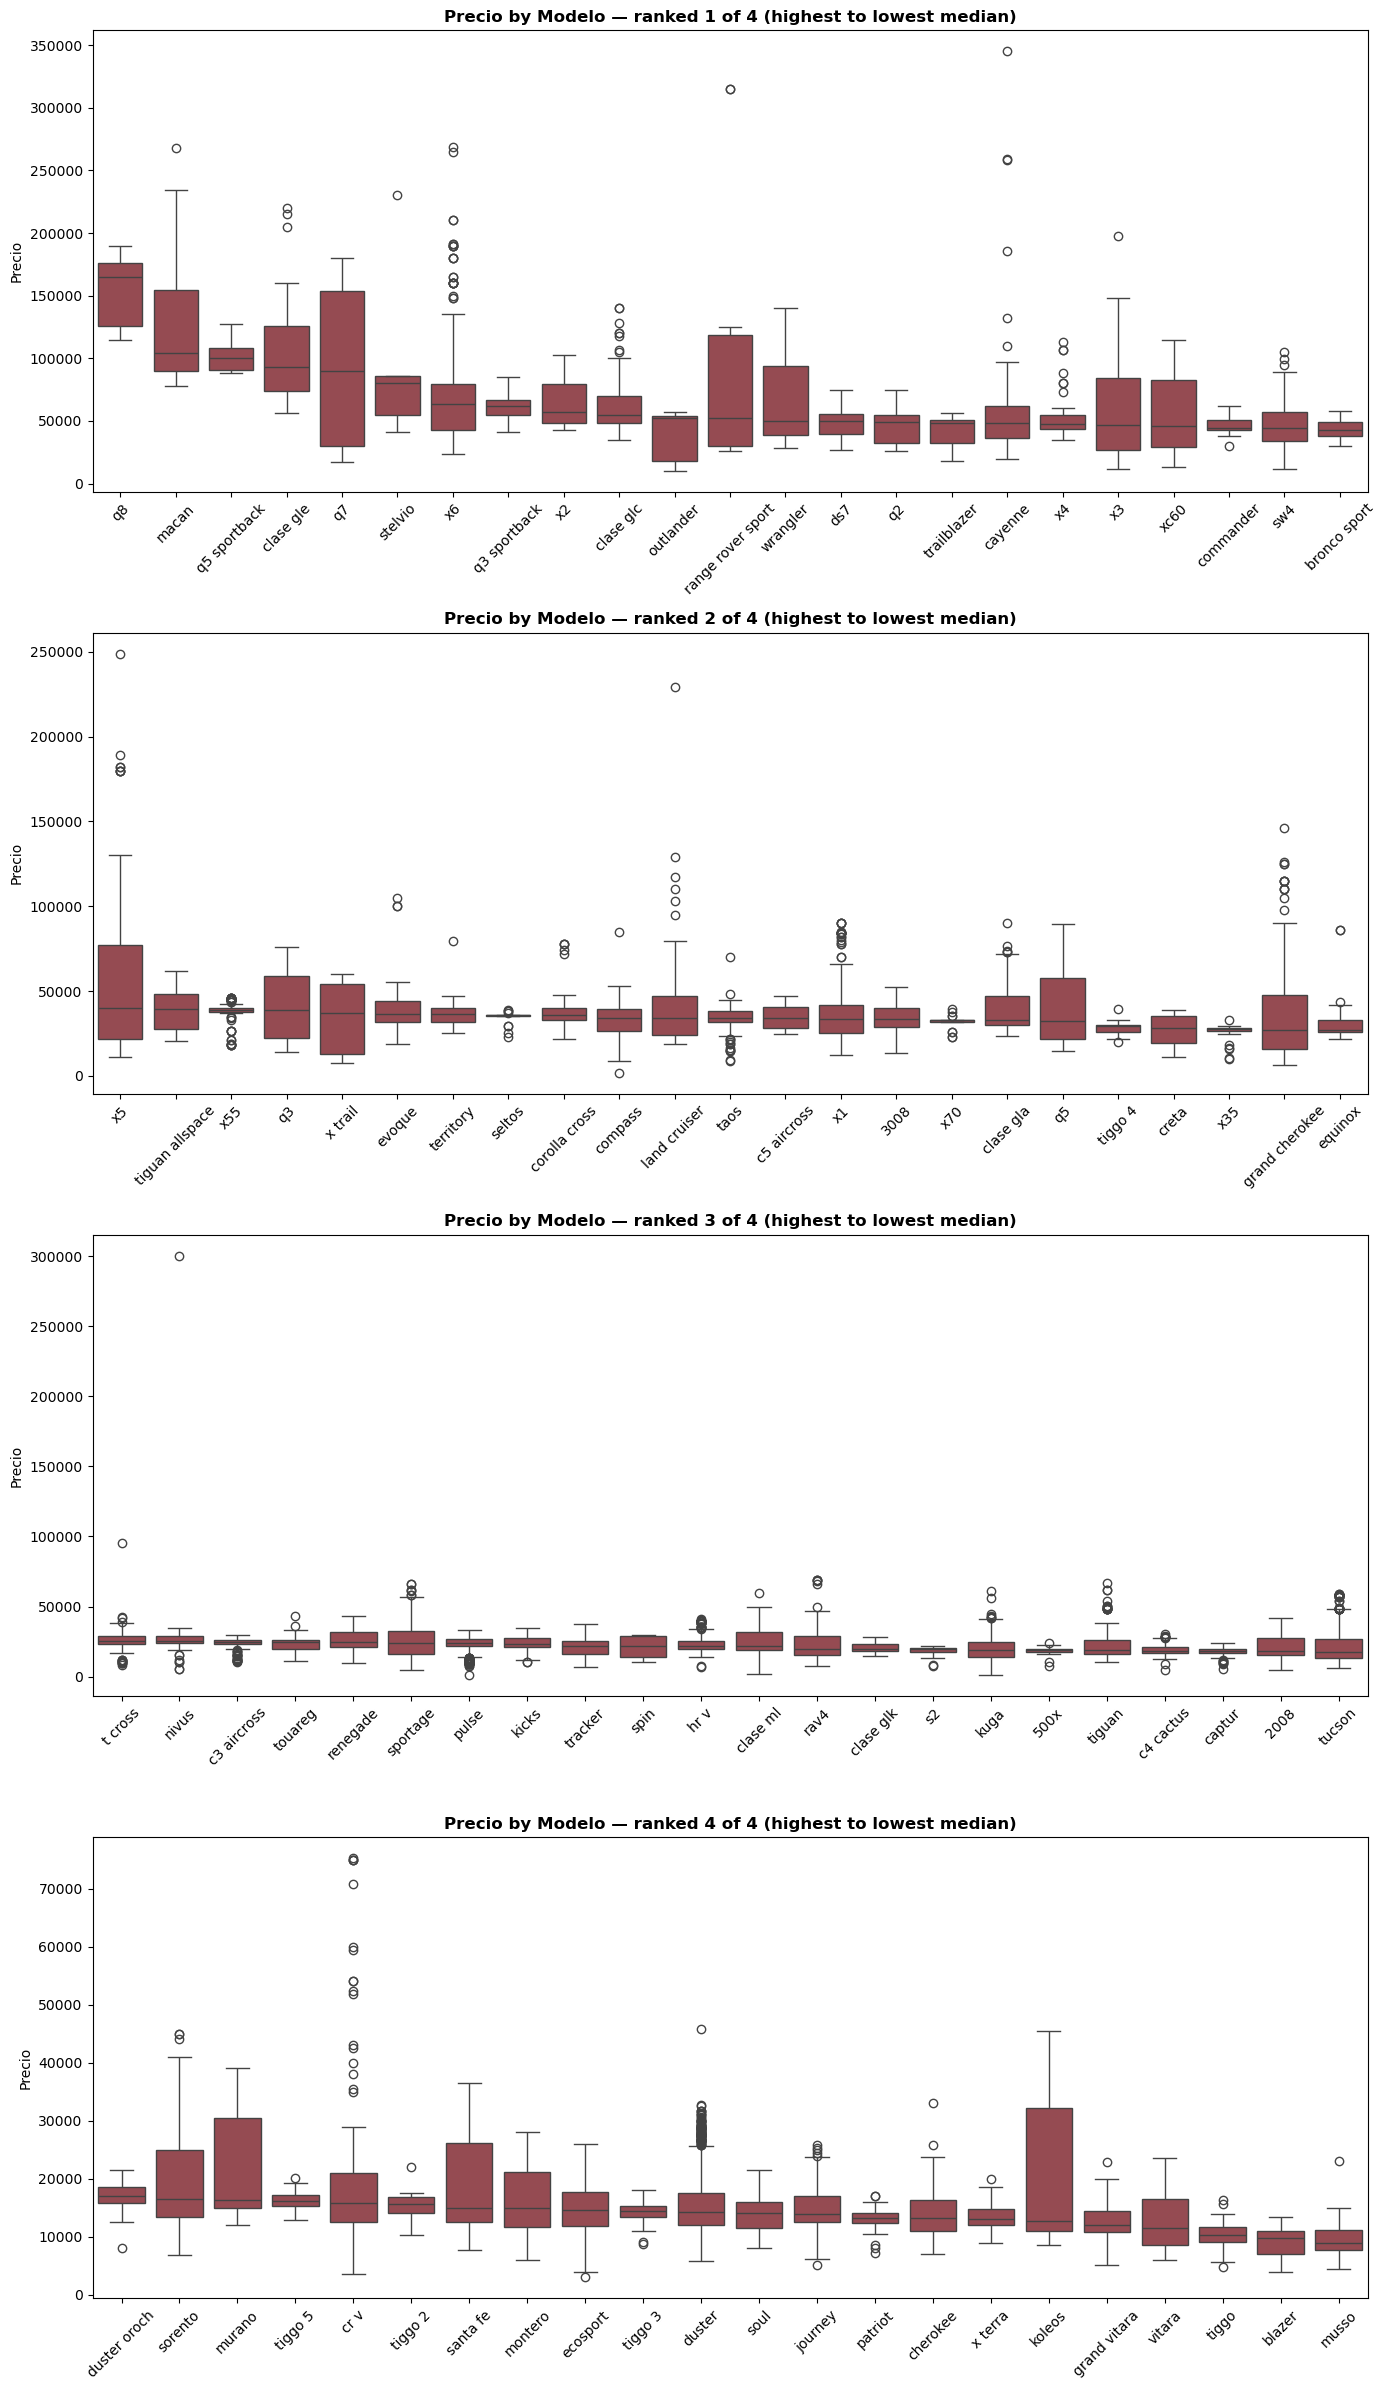

In [260]:
print("======================== Outliers por Marca ========================")
visual.plot_outliers_by_category(dataset_processed, "Marca", min_count=10, n_splits=3)
print("======================== Outliers por Modelo ========================")
visual.plot_outliers_by_category(dataset_processed, "Modelo", min_count=15, n_splits=4)

Durante el análisis de valores extremos se detectó una publicación de un Volkswagen Nivus con un precio cercano a los 300.000 USD, valor que resulta poco consistente con el rango habitual de ese modelo. Este tipo de observaciones puede afectar de forma considerable el entrenamiento y la evaluación del modelo.

Por este motivo, se decidió aplicar criterios de validación de precios diferenciados según el tipo de marca. En particular, se definieron rangos más amplios para marcas que incluyen modelos de alta gama y rangos más restrictivos para el resto, con el objetivo de detectar posibles errores de carga sin eliminar automáticamente vehículos premium cuyo precio elevado puede ser razonable.

In [ ]:
PREMIUM_BRANDS = const.PREMIUM_BRANDS

NON_PREMIUM_PRICE_MIN = 1000
NON_PREMIUM_PRICE_MAX = 150_000

In [ ]:
mask = ~dataset_processed["Marca"].isin(PREMIUM_BRANDS)

dataset_processed.loc[mask, "Precio"] = dataset_processed.loc[mask, "Precio"].clip(
    lower=const.NON_PREMIUM_PRICE_MIN,
    upper=const.NON_PREMIUM_PRICE_MAX,
)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Drop Irrelevant Rows
</div>

En el análisis inicial de duplicados se consideraba el dataset completo, incluyendo la columna **`Unnamed: 0`**. Esta variable funciona como un identificador, ya que toma un valor distinto para cada fila. Por este motivo, si se la incluye en la comparación, dos publicaciones que son iguales en todas sus características pueden no detectarse como duplicadas porque difieren únicamente en ese identificador.

Por eso, luego de eliminar columnas irrelevantes como **`Unnamed: 0`**, se vuelve a revisar la presencia de filas duplicadas y se eliminan los duplicados exactos antes de realizar el split. Esto evita que una misma observación pese más de una vez en el entrenamiento o que aparezca simultáneamente en train y validation.

In [263]:
eda.duplicate_rows_summary(dataset_processed).style.hide(axis="index")

total_rows,duplicate_rows
18223,1236


In [264]:
dataset_processed = dataset_processed.drop_duplicates().reset_index(drop=True)
eda.duplicate_rows_summary(dataset_processed).style.hide(axis="index")

total_rows,duplicate_rows
16987,0


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Load Preprocecssed Dataset
</div>

In [265]:
# Save preprocessed dataset
dataset_processed = dataset_processed.copy()
dataset_processed.to_csv("../data/dataset_pp.csv", index = False)

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Data Splitting
</h3>

Una vez terminadas las transformaciones y la recuperación de información desde texto, se separa el dataset en entrenamiento y validación (80% - 20%)

El split se realiza estratificando por `Marca`, ya que esta variable tiene una distribución desigual y suponemos    que está fuertemente relacionada con el precio. Mantener proporciones similares de marcas en train y validation ayuda a que ambos conjuntos sean más comparables.

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Stratified by Brand
</div>

In [266]:
X_pp = dataset_processed.drop(columns = [TARGET])
y_pp = dataset_processed[TARGET]

In [267]:
train_set, val_set = split.train_val_split_stratified(X_pp, y_pp, stratify_by = X_pp["Marca"], train_size = 0.80)

X_train, y_train = train_set
X_val, y_val = val_set

In [268]:
# Split check
split.split_size_summary(X_train, X_val).style.hide(axis = "index")

split,rows,percentage
train,13591,80.010000
validation,3396,19.990000


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Grouping Low-Frequency Categories
</div>

Antes de aplicar one-hot encoding, se agrupan como `otros` las categorías con menos de 20 observaciones en el conjunto de entrenamiento. Esto reduce la cantidad de columnas generadas y evita que el modelo aprenda patrones demasiado específicos a partir de categorías con muy pocos casos. El agrupamiento se define únicamente con `X_train` y luego se aplica a `X_val`, para mantener el mismo criterio sin introducir información del conjunto de validación.

In [ ]:
rare_category_cols = [
    "Marca",
    "Modelo",
    "Color",
    "Tipo de vendedor",
    "Tipo de combustible",
    "Transmisión",
]

RARE_CATEGORY_MIN_COUNT = 20
RARE_CATEGORY_LABEL = "otros"

X_train, rare_categories_map = prep.group_rare_categories(
    X_train,
    categorical_cols=rare_category_cols,
    min_count=RARE_CATEGORY_MIN_COUNT,
    rare_label=RARE_CATEGORY_LABEL,
    train=True,
)

X_val = prep.group_rare_categories(
    X_val,
    categorical_cols=rare_category_cols,
    categories_map=rare_categories_map,
    rare_label=RARE_CATEGORY_LABEL,
    train=False,
)


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Load Split
</div>

In [270]:
X_train = X_train.copy()
X_val = X_val.copy()

SPLITTED_DATA_DIR = Path("../data/processed/splitted")

X_train.to_csv(SPLITTED_DATA_DIR / "X_train.csv", index=False)
X_val.to_csv(SPLITTED_DATA_DIR / "X_val.csv", index=False)
y_train.to_csv(SPLITTED_DATA_DIR / "y_train.csv", index=False)
y_val.to_csv(SPLITTED_DATA_DIR / "y_val.csv", index=False)


<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
One Hot Encoding
</h3>

Después del split, se aplica one-hot encoding a las variables categóricas. El encoder se ajusta sobre el conjunto de entrenamiento y luego se aplica al conjunto de validación usando las mismas categorías aprendidas.

Este orden evita que el conjunto de validación influya en la definición de las columnas dummy. De esta forma, el preprocesamiento respeta la separación entre train y validation.

In [271]:
X_train_encoded, categories_map = prep.one_hot_encoding(
    X_train,
    categorical_cols=categorical_columns,
    train=True,
    binary_missing_cols = ["Con cámara de retroceso"],
)

X_val_encoded = prep.one_hot_encoding(
    X_val,
    categorical_cols=categorical_columns,
    train=False,
    categories_map=categories_map,
    binary_missing_cols = ["Con cámara de retroceso"],
)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Load Split + One-hot
</div>

In [272]:
X_train_encoded = X_train_encoded.copy()
X_val_encoded = X_val_encoded.copy()

ONE_HOT_DATA_DIR = Path("../data/processed/one_hot")

X_train_encoded.to_csv(ONE_HOT_DATA_DIR / "X_train_encoded.csv", index=False)
X_val_encoded.to_csv(ONE_HOT_DATA_DIR / "X_val_encoded.csv", index=False)


<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Checking preprocessed dataset
</h3>

In [273]:
eda.missing_values_summary(X_train_encoded).style.hide(axis="index")

column,missing_count,missing_percentage
Cilindrada,14,0.100000


In [274]:
eda.unique_values_summary(X_train_encoded).style.hide(axis="index")

column,unique_values,unique_pct
Descripción,9891,72.780000
Título,1947,14.330000
Kilómetros,1853,13.630000
Versión,1826,13.440000
Cilindrada,42,0.310000
Año,37,0.270000
Puertas,4,0.030000
Con cámara de retroceso,2,0.010000
Tiene turbo,2,0.010000
papeles,2,0.010000


In [275]:
eda.duplicate_rows_summary(dataset_processed).style.hide(axis="index")

total_rows,duplicate_rows
16987,0


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Output Files
</div>

Al finalizar este notebook quedan guardados los siguientes archivos:

- `../data/dataset_pp.csv`: dataset completo preprocesado, antes del split.
- `../data/processed/splitted/X_train.csv` y `X_val.csv`: features separadas en train y validation, antes del one-hot.
- `../data/processed/splitted/y_train.csv` y `y_val.csv`: target correspondiente a cada split.
- `../data/processed/one_hot/X_train_encoded.csv` y `X_val_encoded.csv`: versión one-hot base para modelado.

El one-hot se guarda como una versión base porque varios modelos lo necesitan directamente. Aun así, las pruebas de feature engineering pueden volver a partir de los splits pre-one-hot cuando se quiera construir una codificación alternativa.